Following this for Manhattan plots
https://danielroelfs.com/blog/how-i-create-manhattan-plots-using-ggplot/

# Setup

In [6]:
conda activate /broad/sankaranlab/arora/conda_envs/scavenge

ERROR: Error in parse(text = x, srcfile = src): <text>:1:7: unexpected symbol
1: conda activate
          ^


In [7]:
#Moved all my packages from my home directopry to my directory because my home directory was filling up!
#lib.loc = "/broad/sankaranlab/arora/R_packages/library"
#In scavenge conda environment
lib.loc <- "/broad/sankaranlab/arora/conda_envs/scavenge/lib/R/library"

In [ ]:
%%bash 

#Need to install cmake before trying to install
cd /broad/sankaranlab/arora/tools/
wget https://cmake.org/files/v3.4/cmake-3.4.1-Linux-x86_64.tar.gz
tar xf cmake-3.4.1-Linux-x86_64.tar.gz
#Installing packages that require cmake - have to do this each time I activate the conda environment?
export PATH="/broad/sankaranlab/arora/tools/cmake-3.4.1-Linux-x86_64/bin:$PATH"

In [8]:
library(ggrepel)
library(magrittr)

In [9]:
library(ggpubr, lib.loc = lib.loc)

In [4]:
#install.packages("qqman", lib = lib.loc)
library(qqman, lib.loc = lib.loc)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





In [5]:
library(grid)
library(gridGraphics)

In [6]:
library(gridExtra)

In [10]:
#Packages that are already installed
library(tidyverse)
library(data.table)

-- Attaching core tidyverse packages ------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v lubridate 1.9.3     v tibble    3.2.1
v purrr     1.0.2     v tidyr     1.3.1
-- Conflicts ------------------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse_conflicts() --
x tidyr::extract()   masks magrittr::extract()
x dplyr::filter()    masks stats::filter()
x dplyr::lag()       masks stats::lag()
x purrr::set_names() masks magrittr::set_names()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'data.table'


The following objects are masked from 'package:lubridate':

    hour, isoweek, mday, minute, month, quarter, second, wday,

In [11]:
#Packages I have installed, have to specify library location
#remotes::install_github("wilkelab/ggtext", lib = lib.loc)
library(ggtext, lib.loc = lib.loc )
#devtools::install_github("norment/normentR", lib = lib.loc)
library(normentR, lib.loc = lib.loc)

Loading required package: png

-----------------------------------------------------------------

Welcome to the {normentR} package!

Version: 0.1.6

If there's any questions about how to use this package,

  please ask Daniel in B48!

The default ggplot theme has been replaced with theme_norment()

-----------------------------------------------------------------



In [9]:
#install.packages("svglite", lib = lib.loc)
library("svglite", lib.loc = lib.loc)

In [10]:
#remotes::install_github("YuLab-SMU/ggbreak")
library("ggbreak", lib.loc = lib.loc)

ggbreak v0.1.2

If you use ggbreak in published research, please cite the following
paper:

S Xu, M Chen, T Feng, L Zhan, L Zhou, G Yu. Use ggbreak to effectively
utilize plotting space to deal with large datasets and outliers.
Frontiers in Genetics. 2021, 12:774846. doi: 10.3389/fgene.2021.774846




# Main manhattan plot, Figure 1B

## NEW META GWAS - with tanzania cohort from google cloud bucket from Baraka

In [10]:
META <- fread('/broad/sankaranlab/arora/hbf/reviews/FEMA/with_tanz_hbf/CloudTanz_METALOUT_inv_1.tbl')
META$`P-value` <- as.numeric(META$`P-value`)
META <- META[META$`P-value` > 0,]
META$`P-value`[is.infinite(META$`P-value`)] <- NA
META <- na.omit(META)
nrow(META)

[1] 28621448

In [ ]:
#remove anythingnwith p > 0.01 (too many dots in plot)
META <- META[META$`P-value` < 0.001,]

In [8]:
sig <- 0.05 / nrow(META)

data_cum <- META |>
  group_by(Chromosome) |>
  summarise(max_bp = max(Position)) |>
  mutate(bp_add = lag(cumsum(max_bp), default = 0)) |>
  select(Chromosome, bp_add)

META <- META |>
  inner_join(data_cum, by = "Chromosome") |>
  mutate(bp_cum = Position + bp_add)

axis_set <- META |>
  group_by(Chromosome) |>
  summarize(center = mean(bp_cum))

ylim <- META |>
  filter(`P-value` == min(`P-value`)) |>
  mutate(ylim = abs(floor(log10(`P-value`))) + 2) |>
  pull(ylim)

In [9]:
manhplot <- ggplot(META, aes(
  x = bp_cum, y = -log10(`P-value`),
  color = as_factor(Chromosome), size = -log10(`P-value`)
)) +
  geom_hline(
    yintercept = -log10(sig), color = "grey40",
    linetype = "dashed"
  ) +
  geom_point() +
  scale_x_continuous(
    label = axis_set$Chromosome,
    breaks = axis_set$center
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, ylim)) +
  scale_y_break(c(30, 150)) +
  scale_color_manual(values = rep(
    c("#6C757D", "#7B44E4"),
    unique(length(axis_set$Chromosome))
  )) +
  scale_size_continuous(range = c(0.5, 3)) +
  labs(
    x = NULL,
    y = "-log<sub>10</sub>(p)"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.title.y = element_markdown(),
    axis.text.x = element_text(angle = 60, size = 8, vjust = 0.5)
  )

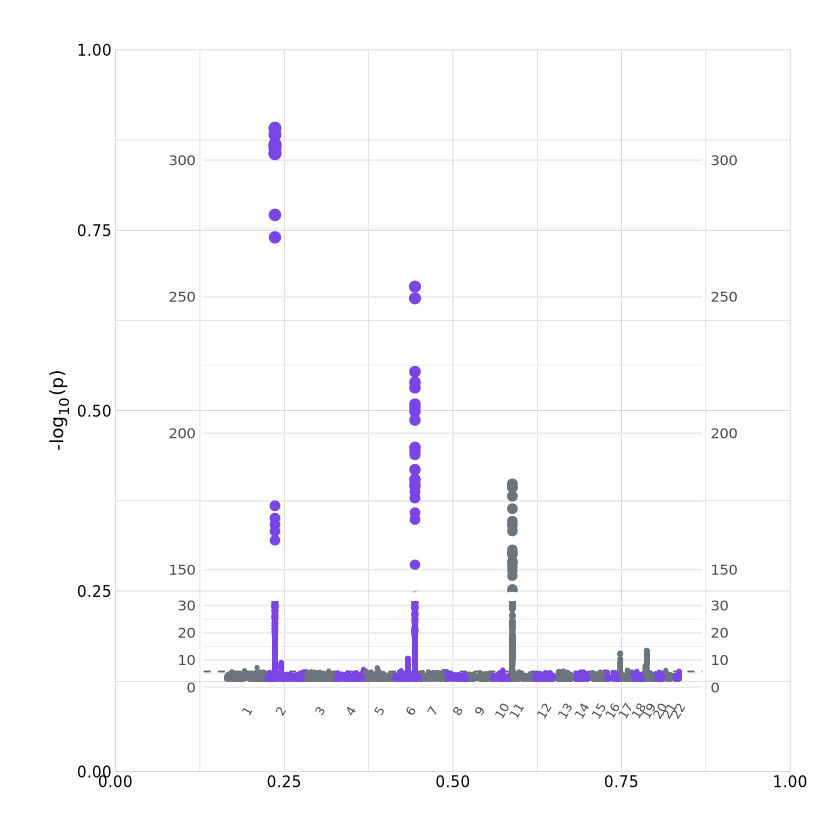

In [10]:
print(manhplot)

In [11]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1B_noalpha.svg", plot = manhplot, device = "svg")

Saving 6.67 x 6.67 in image


In [12]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1B_noalpha.eps", plot = manhplot, device = "eps")

Saving 6.67 x 6.67 in image


# MAMA plots, Figure 1C,D,E

## New MAMA analysis with cloud tanzania dataset

### EUR

In [25]:
EUR <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_EUR_HBF.res')


In [26]:
head(EUR)

SNP,CHR,BP,A1,A2,FREQ,BETA,SE,Z,P,N_EFF,N_ORIG
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1:798969:t:c,1,798969,C,T,0.131811,0.0143077073,0.01771792,0.80752732,0.4193627,15539.32,11004
1:822354:c:t,1,822354,T,C,0.867169,-0.0007251404,0.01732270,-0.04186071,0.9666097,14913.47,11004
1:836587:g:a,1,836587,A,G,0.130364,0.0016985439,0.01676062,0.10134138,0.9192795,16117.50,11004
1:843365:a:g,1,843365,G,A,0.131084,0.0019817189,0.01637120,0.12104913,0.9036521,16707.51,11004
1:843942:a:g,1,843942,G,A,0.125747,-0.0050933805,0.01698124,-0.29994160,0.7642217,17328.93,11004
1:847601:c:t,1,847601,T,C,0.132595,-0.0065223851,0.01714501,-0.38042475,0.7036301,16460.55,11004


In [27]:
EUR$BP <- as.numeric(EUR$BP)

In [28]:
EUR <- EUR[EUR$P < 0.01,]

In [10]:
sig <- 0.05 / nrow(EUR)

data_cum <- EUR |>
  group_by(CHR) |>
  summarise(max_bp = max(BP)) |>
  mutate(bp_add = lag(cumsum(max_bp), default = 0)) |>
  select(CHR, bp_add)

EUR <- EUR |>
  inner_join(data_cum, by = "CHR") |>
  mutate(bp_cum = BP + bp_add)

axis_set <- EUR |>
  group_by(CHR) |>
  summarize(center = mean(bp_cum))

ylim <- EUR |>
  filter(P == min(P)) |>
  mutate(ylim = abs(floor(log10(P))) + 2) |>
  pull(ylim)

In [11]:
manhplot <- ggplot(EUR, aes(
  x = bp_cum, y = -log10(P),
  color = as_factor(CHR), size = -log10(P)
)) +
  geom_hline(
    yintercept = -log10(sig), color = "grey40",
    linetype = "dashed"
  ) +
  geom_point() +
  scale_x_continuous(
    label = axis_set$CHR,
    breaks = axis_set$center
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, ylim)) +
  scale_color_manual(values = rep(
    c("#276FBF", "#183059"),
    unique(length(axis_set$CHR))
  )) +
  scale_size_continuous(range = c(0.5, 3)) +
  labs(
    x = NULL,
    y = "-log<sub>10</sub>(p)"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.title.y = element_markdown(),
    axis.text.x = element_text(angle = 60, size = 8, vjust = 0.5)
  )

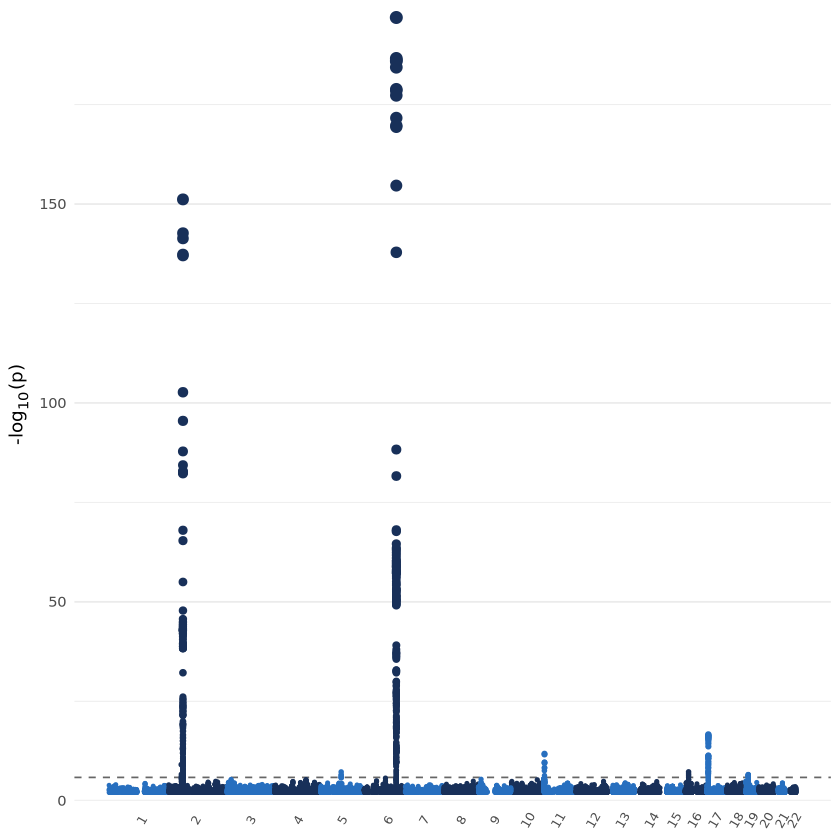

In [12]:
print(manhplot)

In [13]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1D_noalpha.svg", plot = manhplot, device = "svg")

Saving 6.67 x 6.67 in image


In [14]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1D_noalpha.eps", plot = manhplot, device = "eps")

Saving 6.67 x 6.67 in image


### AFR

In [16]:
AFR <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_AFR_HBF.res')

In [17]:
AFR$BP <- as.numeric(AFR$BP)
AFR <- AFR[AFR$P < 0.01,]


In [18]:
sig <- 0.000001

data_cum <- AFR |>
  group_by(CHR) |>
  summarise(max_bp = max(BP)) |>
  mutate(bp_add = lag(cumsum(max_bp), default = 0)) |>
  select(CHR, bp_add)

AFR <- AFR |>
  inner_join(data_cum, by = "CHR") |>
  mutate(bp_cum = BP + bp_add)

axis_set <- AFR |>
  group_by(CHR) |>
  summarize(center = mean(bp_cum))

ylim <- AFR |>
  filter(P == min(P)) |>
  mutate(ylim = abs(floor(log10(P))) + 2) |>
  pull(ylim)

In [19]:
manhplot <- ggplot(AFR, aes(
  x = bp_cum, y = -log10(P),
  color = as_factor(CHR), size = -log10(P)
)) +
  geom_hline(
    yintercept = -log10(sig), color = "grey40",
    linetype = "dashed"
  ) +
  geom_point() +
  scale_x_continuous(
    label = axis_set$CHR,
    breaks = axis_set$center
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, ylim)) +
  scale_color_manual(values = rep(
    c("#276FBF", "#183059"),
    unique(length(axis_set$CHR))
  )) +
  scale_size_continuous(range = c(0.5, 3)) +
  labs(
    x = NULL,
    y = "-log<sub>10</sub>(p)"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.title.y = element_markdown(),
    axis.text.x = element_text(angle = 60, size = 8, vjust = 0.5)
  )

In [20]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1C_noalpha.svg", plot = manhplot, device = "svg")
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1C_noalpha.eps", plot = manhplot, device = "eps")

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


### EAS

In [21]:
EAS <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_THAI_HBF.res')

In [22]:
EAS$BP <- as.numeric(EAS$BP)
EAS <- EAS[EAS$P < 0.01,]


In [22]:
sig <- 0.05 / nrow(EAS)

data_cum <- EAS |>
  group_by(CHR) |>
  summarise(max_bp = max(BP)) |>
  mutate(bp_add = lag(cumsum(max_bp), default = 0)) |>
  select(CHR, bp_add)

EAS <- EAS |>
  inner_join(data_cum, by = "CHR") |>
  mutate(bp_cum = BP + bp_add)

axis_set <- EAS |>
  group_by(CHR) |>
  summarize(center = mean(bp_cum))

ylim <- EAS |>
  filter(P == min(P)) |>
  mutate(ylim = abs(floor(log10(P))) + 2) |>
  pull(ylim)

In [23]:
manhplot <- ggplot(EAS, aes(
  x = bp_cum, y = -log10(P),
  color = as_factor(CHR), size = -log10(P)
)) +
  geom_hline(
    yintercept = -log10(sig), color = "grey40",
    linetype = "dashed"
  ) +
  geom_point() +
  scale_x_continuous(
    label = axis_set$CHR,
    breaks = axis_set$center
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, ylim)) +
  scale_color_manual(values = rep(
    c("#276FBF", "#183059"),
    unique(length(axis_set$CHR))
  )) +
  scale_size_continuous(range = c(0.5, 3)) +
  labs(
    x = NULL,
    y = "-log<sub>10</sub>(p)"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.title.y = element_markdown(),
    axis.text.x = element_text(angle = 60, size = 8, vjust = 0.5)
  )


In [24]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1E_noalpha.svg", plot = manhplot, device = "svg")
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/Figure1E_noalpha.eps", plot = manhplot, device = "eps")

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


# QQ-plots Extended data figure 1A,B,C,D

## META GWAS

In [22]:
META <- fread('/broad/sankaranlab/arora/hbf/reviews/FEMA/with_tanz_hbf/CloudTanz_METALOUT_inv_1.tbl')
META$`P-value` <- as.numeric(META$`P-value`)
META <- META[META$`P-value` > 0,]
META$`P-value`[is.infinite(META$`P-value`)] <- NA
META <- na.omit(META)
nrow(META)

[1] 28621448

In [11]:
postscript("/broad/sankaranlab/arora/hbf/reviews/figures/qq_META.eps", width = 3, height = 3)  # Adjust width and height as needed
qq(META$`P-value`)
alpha<-median(qchisq(1-META$`P-value`,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )
dev.off()

png 
  2

In [12]:
postscript("/broad/sankaranlab/arora/hbf/reviews/figures/qq_META.png", width = 3, height = 3)  # Adjust width and height as needed
qq(META$`P-value`)
#alpha<-median(qchisq(1-META$`P-value`,1))/qchisq(0.5,1)
#text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )
dev.off()

png 
  2

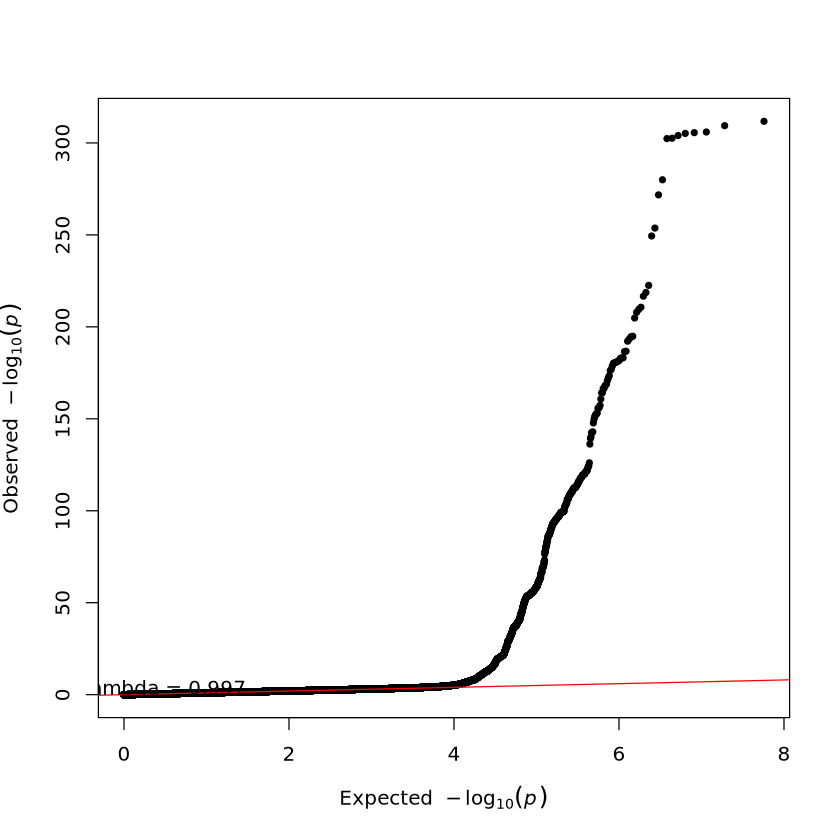

In [13]:
qq(META$`P-value`)
alpha<-median(qchisq(1-META$`P-value`,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )

In [31]:
ci <- 0.95
n  <- nrow(META)
log10Pe <- expression(paste("Expected -log"[10], plain(P)))
log10Po <- expression(paste("Observed -log"[10], plain(P)))

dt3 <- META %>% 
            arrange(`P-value`) %>%
            mutate(observed = -log10(`P-value`)) %>%
            mutate(expected = -log10(ppoints(n))) %>%
            mutate(clower = -log10(qbeta(p = (1 - ci) / 2, shape1 = 1:n, shape2 = n:1))) %>% 
            mutate(cupper = -log10(qbeta(p = (1 + ci) / 2, shape1 = 1:n, shape2 = n:1)))

qq1 <- ggplot(dt3) + 
#    geom_ribbon(mapping = aes(x = expected, ymin = clower, ymax = cupper), alpha = 0.1) +
    geom_point(aes(expected, observed), shape = 16, size = 3) +
#    geom_point(data=dt2 %>% filter(Pfdr<0.05), aes(expected, observed, color=Gene), inherit.aes=FALSE, shape = 16, size = 3) +
    geom_abline(intercept = 0, slope = 1, alpha = 0.5) +
    # geom_line(aes(expected, cupper), linetype = 2, size = 0.5) +
    # geom_line(aes(expected, clower), linetype = 2, size = 0.5) +
    xlab(log10Pe) +
    ylab(log10Po) + 
#    geom_label_repel(data=dt2 %>% filter(Pfdr<0.05), 
#                     aes(label=Gene, x=expected, y=observed, fill=factor(Gene)), 
#                     min.segment.length = 0, seed = 42, box.padding = 0.5, 
#                     max.overlaps = Inf, color="white",segment.colour="black", size=6) +
#    geom_label(data=dt2 %>% filter(Pfdr<0.05), aes(label=Gene, x=expected, y=observed)) + 
    scale_fill_viridis_d() + scale_color_viridis_d() + 
    theme_pubr() + theme(legend.position="none", text=element_text(size=16)) 
#    ylim(0,25)

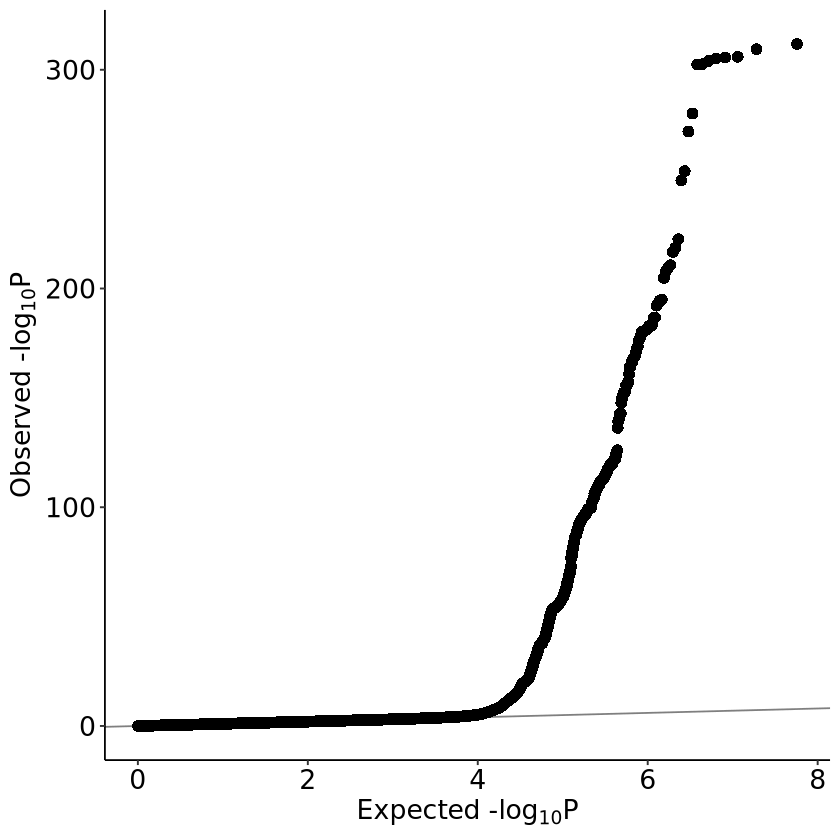

In [15]:
qq1

In [31]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_1.pdf', plot = qq1, device = "pdf", width = 3, height = 3)


In [32]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_1.png', plot = qq1, device = "png", width = 4, height = 4)


In [33]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_1_dpi50.pdf', plot = qq1, device = "pdf", width = 3, height = 3, dpi = 50)


In [27]:
random.logical_vector<-as.logical(rbinom(length(META[[1]]), 1, .01))
META_subset <- META[random.logical_vector,]

In [28]:
ci <- 0.95
n  <- nrow(META_subset)
log10Pe <- expression(paste("Expected -log"[10], plain(P)))
log10Po <- expression(paste("Observed -log"[10], plain(P)))

dt3 <- META_subset %>% 
            arrange(`P-value`) %>%
            mutate(observed = -log10(`P-value`)) %>%
            mutate(expected = -log10(ppoints(n))) %>%
            mutate(clower = -log10(qbeta(p = (1 - ci) / 2, shape1 = 1:n, shape2 = n:1))) %>% 
            mutate(cupper = -log10(qbeta(p = (1 + ci) / 2, shape1 = 1:n, shape2 = n:1)))

qq1 <- ggplot(dt3) + 
#    geom_ribbon(mapping = aes(x = expected, ymin = clower, ymax = cupper), alpha = 0.1) +
    geom_point(aes(expected, observed), shape = 16, size = 3) +
#    geom_point(data=dt2 %>% filter(Pfdr<0.05), aes(expected, observed, color=Gene), inherit.aes=FALSE, shape = 16, size = 3) +
    geom_abline(intercept = 0, slope = 1, alpha = 0.5) +
    # geom_line(aes(expected, cupper), linetype = 2, size = 0.5) +
    # geom_line(aes(expected, clower), linetype = 2, size = 0.5) +
    xlab(log10Pe) +
    ylab(log10Po) + 
#    geom_label_repel(data=dt2 %>% filter(Pfdr<0.05), 
#                     aes(label=Gene, x=expected, y=observed, fill=factor(Gene)), 
#                     min.segment.length = 0, seed = 42, box.padding = 0.5, 
#                     max.overlaps = Inf, color="white",segment.colour="black", size=6) +
#    geom_label(data=dt2 %>% filter(Pfdr<0.05), aes(label=Gene, x=expected, y=observed)) + 
    scale_fill_viridis_d() + scale_color_viridis_d() + 
    theme_pubr() + theme(legend.position="none", text=element_text(size=16)) 
#    ylim(0,25)

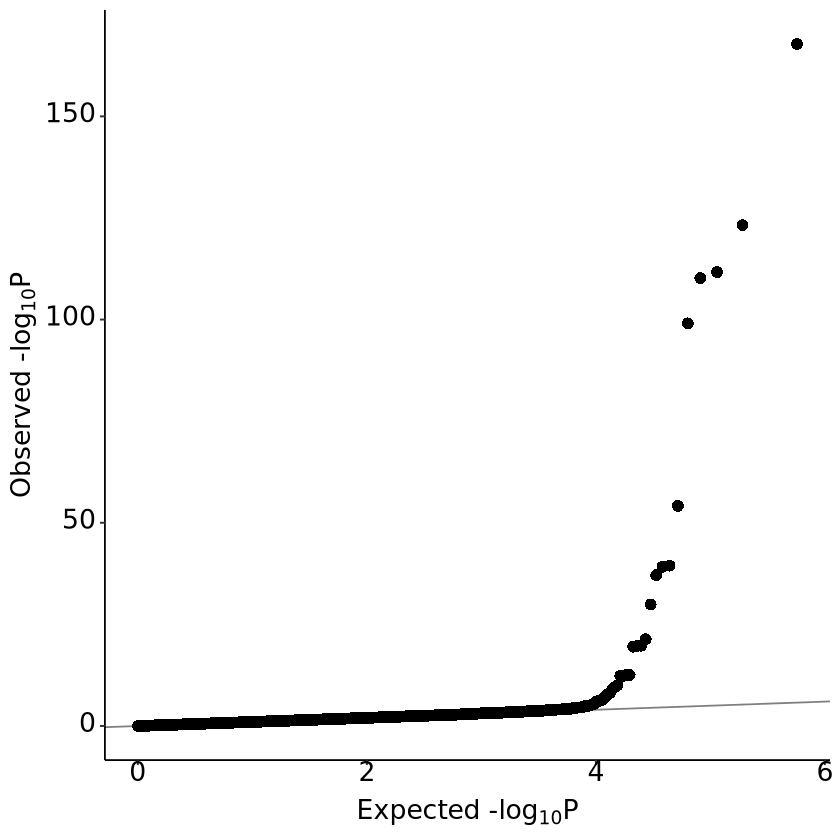

In [29]:
qq1

In [30]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_1_subset.pdf', plot = qq1, device = "pdf", width = 3, height = 3)


In [34]:
rm(META)

## MAMA THAI

In [35]:
EAS <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_THAI_HBF.res')


In [36]:
head(EAS)

SNP,CHR,BP,A1,A2,FREQ,BETA,SE,Z,P,N_EFF,N_ORIG
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1:798969:t:c,1,798969,C,T,0.07895157,0.044397700,0.05751647,0.7719128,0.4401661,2663.365,1392
1:822354:c:t,1,822354,T,C,0.84934753,-0.005322423,0.04242383,-0.1254583,0.9001607,3634.177,1392
1:836587:g:a,1,836587,A,G,0.07276969,0.012390107,0.05187625,0.2388397,0.8112299,3088.812,1392
1:843365:a:g,1,843365,G,A,0.07996838,0.011338191,0.05109150,0.2219193,0.8243767,2691.863,1392
1:843942:a:g,1,843942,G,A,0.08028875,-0.006894183,0.05142360,-0.1340665,0.8933500,2638.726,1392
1:847601:c:t,1,847601,T,C,0.16684487,-0.004311357,0.03900695,-0.1105279,0.9119907,1965.869,1392


In [19]:
postscript("/broad/sankaranlab/arora/hbf/reviews/figures/qq_MAMA_THAI.eps", width = 3, height = 3)  # Adjust width and height as needed
qq(EAS$P)
alpha<-median(qchisq(1-EAS$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )
dev.off()

png 
  2

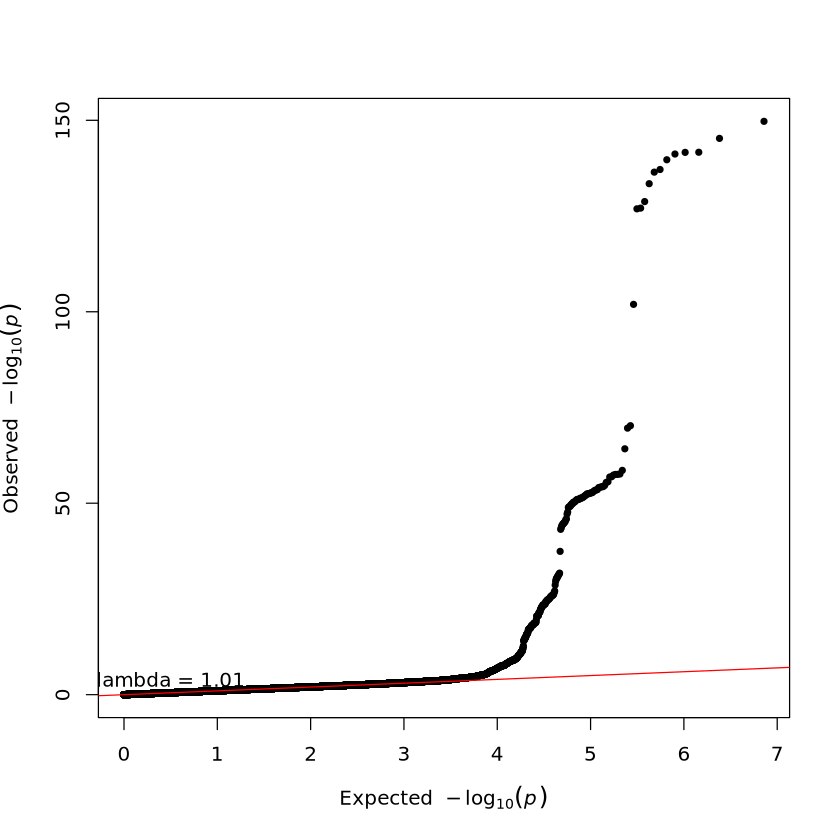

In [20]:
qq(EAS$P)
alpha<-median(qchisq(1-EAS$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )

In [37]:
ci <- 0.95
n  <- nrow(EAS)
log10Pe <- expression(paste("Expected -log"[10], plain(P)))
log10Po <- expression(paste("Observed -log"[10], plain(P)))

dt3 <- EAS %>% 
            arrange(P) %>%
            mutate(observed = -log10(P)) %>%
            mutate(expected = -log10(ppoints(n))) %>%
            mutate(clower = -log10(qbeta(p = (1 - ci) / 2, shape1 = 1:n, shape2 = n:1))) %>% 
            mutate(cupper = -log10(qbeta(p = (1 + ci) / 2, shape1 = 1:n, shape2 = n:1)))

qq4 <- ggplot(dt3) + 
#    geom_ribbon(mapping = aes(x = expected, ymin = clower, ymax = cupper), alpha = 0.1) +
    geom_point(aes(expected, observed), shape = 16, size = 3) +
#    geom_point(data=dt2 %>% filter(Pfdr<0.05), aes(expected, observed, color=Gene), inherit.aes=FALSE, shape = 16, size = 3) +
    geom_abline(intercept = 0, slope = 1, alpha = 0.5) +
    # geom_line(aes(expected, cupper), linetype = 2, size = 0.5) +
    # geom_line(aes(expected, clower), linetype = 2, size = 0.5) +
    xlab(log10Pe) +
    ylab(log10Po) + 
#    geom_label_repel(data=dt2 %>% filter(Pfdr<0.05), 
#                     aes(label=Gene, x=expected, y=observed, fill=factor(Gene)), 
#                     min.segment.length = 0, seed = 42, box.padding = 0.5, 
#                     max.overlaps = Inf, color="white",segment.colour="black", size=6) +
#    geom_label(data=dt2 %>% filter(Pfdr<0.05), aes(label=Gene, x=expected, y=observed)) + 
    scale_fill_viridis_d() + scale_color_viridis_d() + 
    theme_pubr() + theme(legend.position="none", text=element_text(size=16)) 
#    ylim(0,25)

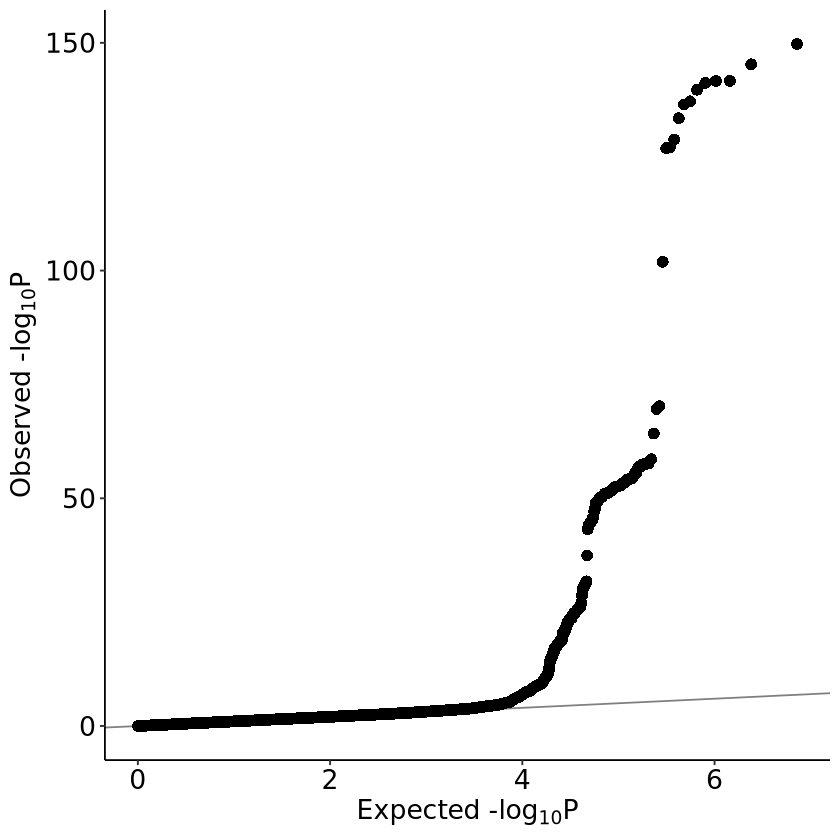

In [22]:
qq4

In [30]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_4.pdf', plot = qq4, device = "pdf", width = 3, height = 3)


In [50]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_4.png', plot = qq4, device = "png", width = 4, height = 4)


In [39]:
rm(EAS)

## MAMA EUR

In [40]:
EUR <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_EUR_HBF.res')


In [41]:
head(EUR)

SNP,CHR,BP,A1,A2,FREQ,BETA,SE,Z,P,N_EFF,N_ORIG
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1:798969:t:c,1,798969,C,T,0.131811,0.0143077073,0.01771792,0.80752732,0.4193627,15539.32,11004
1:822354:c:t,1,822354,T,C,0.867169,-0.0007251404,0.01732270,-0.04186071,0.9666097,14913.47,11004
1:836587:g:a,1,836587,A,G,0.130364,0.0016985439,0.01676062,0.10134138,0.9192795,16117.50,11004
1:843365:a:g,1,843365,G,A,0.131084,0.0019817189,0.01637120,0.12104913,0.9036521,16707.51,11004
1:843942:a:g,1,843942,G,A,0.125747,-0.0050933805,0.01698124,-0.29994160,0.7642217,17328.93,11004
1:847601:c:t,1,847601,T,C,0.132595,-0.0065223851,0.01714501,-0.38042475,0.7036301,16460.55,11004


In [26]:
postscript("/broad/sankaranlab/arora/hbf/reviews/figures/qq_MAMA_EUR.eps", width = 3, height = 3)  # Adjust width and height as needed
qq(EUR$P)
alpha<-median(qchisq(1-EUR$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )
dev.off()

png 
  2

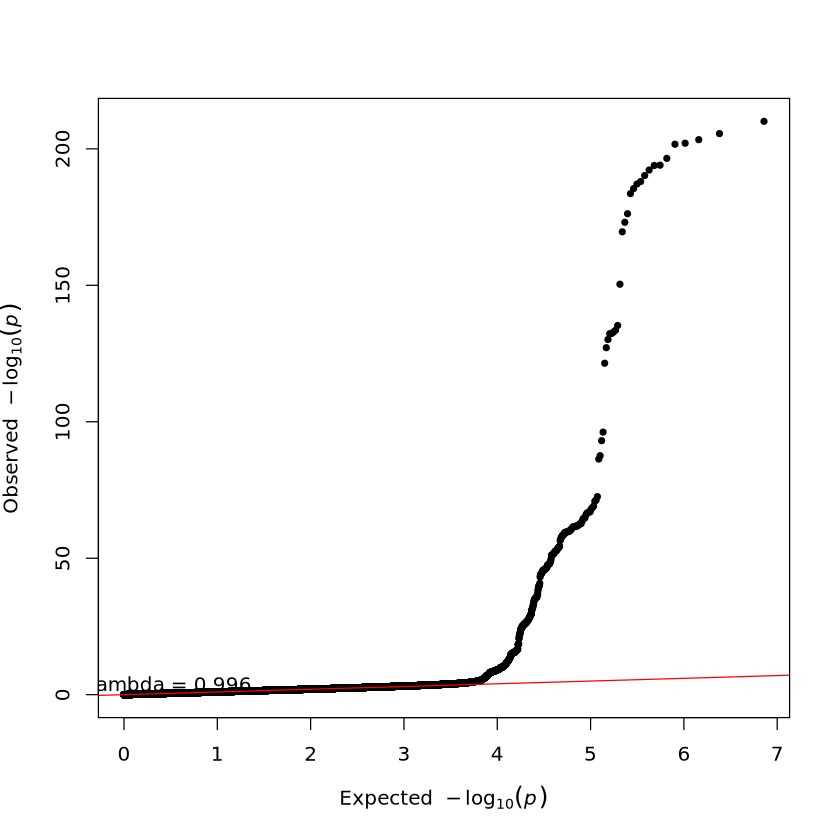

In [27]:
qq(EUR$P)
alpha<-median(qchisq(1-EUR$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )

In [42]:
ci <- 0.95
n  <- nrow(EUR)
log10Pe <- expression(paste("Expected -log"[10], plain(P)))
log10Po <- expression(paste("Observed -log"[10], plain(P)))

dt3 <- EUR %>% 
            arrange(P) %>%
            mutate(observed = -log10(P)) %>%
            mutate(expected = -log10(ppoints(n))) %>%
            mutate(clower = -log10(qbeta(p = (1 - ci) / 2, shape1 = 1:n, shape2 = n:1))) %>% 
            mutate(cupper = -log10(qbeta(p = (1 + ci) / 2, shape1 = 1:n, shape2 = n:1)))

qq3 <- ggplot(dt3) + 
#    geom_ribbon(mapping = aes(x = expected, ymin = clower, ymax = cupper), alpha = 0.1) +
    geom_point(aes(expected, observed), shape = 16, size = 3) +
#    geom_point(data=dt2 %>% filter(Pfdr<0.05), aes(expected, observed, color=Gene), inherit.aes=FALSE, shape = 16, size = 3) +
    geom_abline(intercept = 0, slope = 1, alpha = 0.5) +
    # geom_line(aes(expected, cupper), linetype = 2, size = 0.5) +
    # geom_line(aes(expected, clower), linetype = 2, size = 0.5) +
    xlab(log10Pe) +
    ylab(log10Po) + 
#    geom_label_repel(data=dt2 %>% filter(Pfdr<0.05), 
#                     aes(label=Gene, x=expected, y=observed, fill=factor(Gene)), 
#                     min.segment.length = 0, seed = 42, box.padding = 0.5, 
#                     max.overlaps = Inf, color="white",segment.colour="black", size=6) +
#    geom_label(data=dt2 %>% filter(Pfdr<0.05), aes(label=Gene, x=expected, y=observed)) + 
    scale_fill_viridis_d() + scale_color_viridis_d() + 
    theme_pubr() + theme(legend.position="none", text=element_text(size=16)) 
#    ylim(0,25)

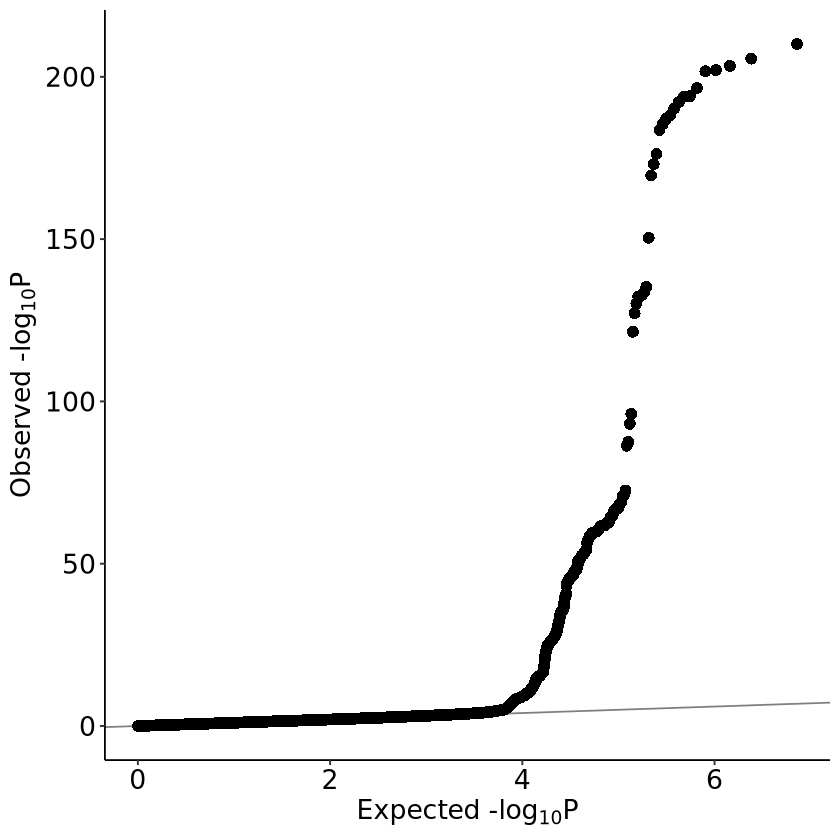

In [29]:
qq3

In [29]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_3.pdf', plot = qq3, device = "pdf", width = 3, height = 3)


In [51]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_3.png', plot = qq3, device = "png", width = 4, height = 4)


In [44]:
rm(EUR)

## MAMA AFR

In [45]:
AFR <- fread('/broad/sankaranlab/arora/hbf/reviews/mama/output/UA_HBF_MAMA_AFR_HBF.res')


In [46]:
head(AFR)

SNP,CHR,BP,A1,A2,FREQ,BETA,SE,Z,P,N_EFF,N_ORIG
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1:798969:t:c,1,798969,C,T,0.127983,0.030448985,0.04564466,0.6670875,0.5047162,2459.672,1187
1:822354:c:t,1,822354,T,C,0.460933,0.012751251,0.03139753,0.4061228,0.6846524,2025.171,1187
1:836587:g:a,1,836587,A,G,0.301839,-0.008304628,0.03239712,-0.2563384,0.7976895,2211.187,1187
1:843365:a:g,1,843365,G,A,0.302960,-0.008069879,0.03188968,-0.2530561,0.8002248,2263.750,1187
1:843942:a:g,1,843942,G,A,0.343587,-0.023730234,0.03098582,-0.7658417,0.4437705,2224.497,1187
1:847601:c:t,1,847601,T,C,0.416291,-0.028871730,0.03008607,-0.9596377,0.3372376,2344.054,1187


In [43]:
postscript("/broad/sankaranlab/arora/hbf/reviews/figures/qq_MAMA_AFR.eps", width = 3, height = 3)  # Adjust width and height as needed
qq(AFR$P)
alpha<-median(qchisq(1-AFR$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )
dev.off()

png 
  2

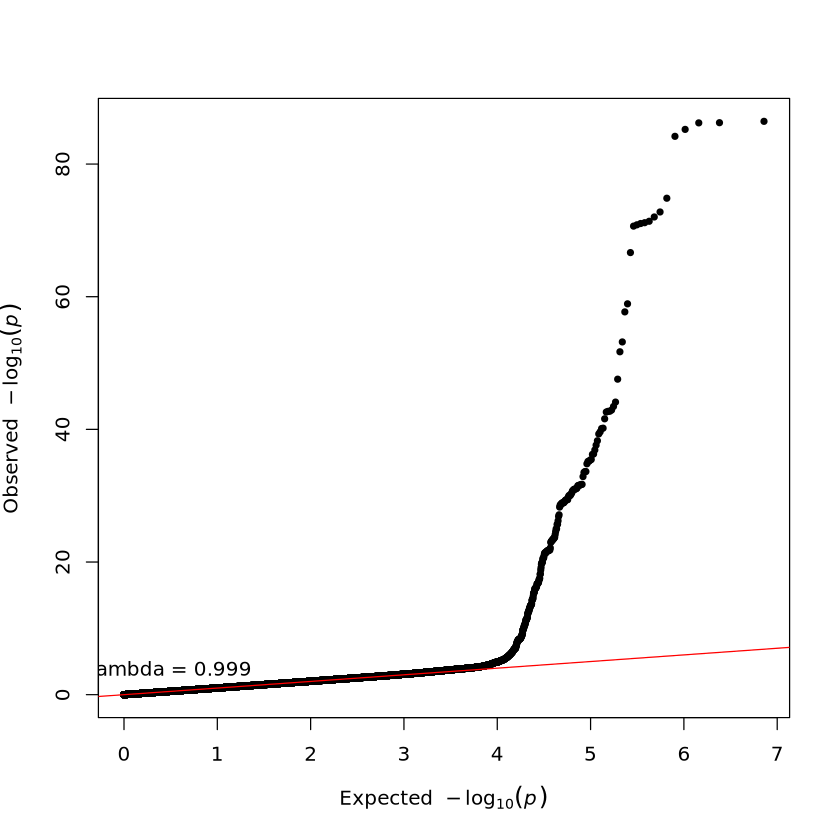

In [44]:
qq(AFR$P)
alpha<-median(qchisq(1-AFR$P,1))/qchisq(0.5,1)
text(0.5,4, paste("lambda","=",  signif(alpha, digits = 3)) )

In [47]:
ci <- 0.95
n  <- nrow(AFR)
log10Pe <- expression(paste("Expected -log"[10], plain(P)))
log10Po <- expression(paste("Observed -log"[10], plain(P)))

dt3 <- AFR %>% 
            arrange(P) %>%
            mutate(observed = -log10(P)) %>%
            mutate(expected = -log10(ppoints(n))) %>%
            mutate(clower = -log10(qbeta(p = (1 - ci) / 2, shape1 = 1:n, shape2 = n:1))) %>% 
            mutate(cupper = -log10(qbeta(p = (1 + ci) / 2, shape1 = 1:n, shape2 = n:1)))

qq2 <- ggplot(dt3) + 
#    geom_ribbon(mapping = aes(x = expected, ymin = clower, ymax = cupper), alpha = 0.1) +
    geom_point(aes(expected, observed), shape = 16, size = 3) +
#    geom_point(data=dt2 %>% filter(Pfdr<0.05), aes(expected, observed, color=Gene), inherit.aes=FALSE, shape = 16, size = 3) +
    geom_abline(intercept = 0, slope = 1, alpha = 0.5) +
    # geom_line(aes(expected, cupper), linetype = 2, size = 0.5) +
    # geom_line(aes(expected, clower), linetype = 2, size = 0.5) +
    xlab(log10Pe) +
    ylab(log10Po) + 
#    geom_label_repel(data=dt2 %>% filter(Pfdr<0.05), 
#                     aes(label=Gene, x=expected, y=observed, fill=factor(Gene)), 
#                     min.segment.length = 0, seed = 42, box.padding = 0.5, 
#                     max.overlaps = Inf, color="white",segment.colour="black", size=6) +
#    geom_label(data=dt2 %>% filter(Pfdr<0.05), aes(label=Gene, x=expected, y=observed)) + 
    scale_fill_viridis_d() + scale_color_viridis_d() + 
    theme_pubr() + theme(legend.position="none", text=element_text(size=16)) 
#    ylim(0,25)

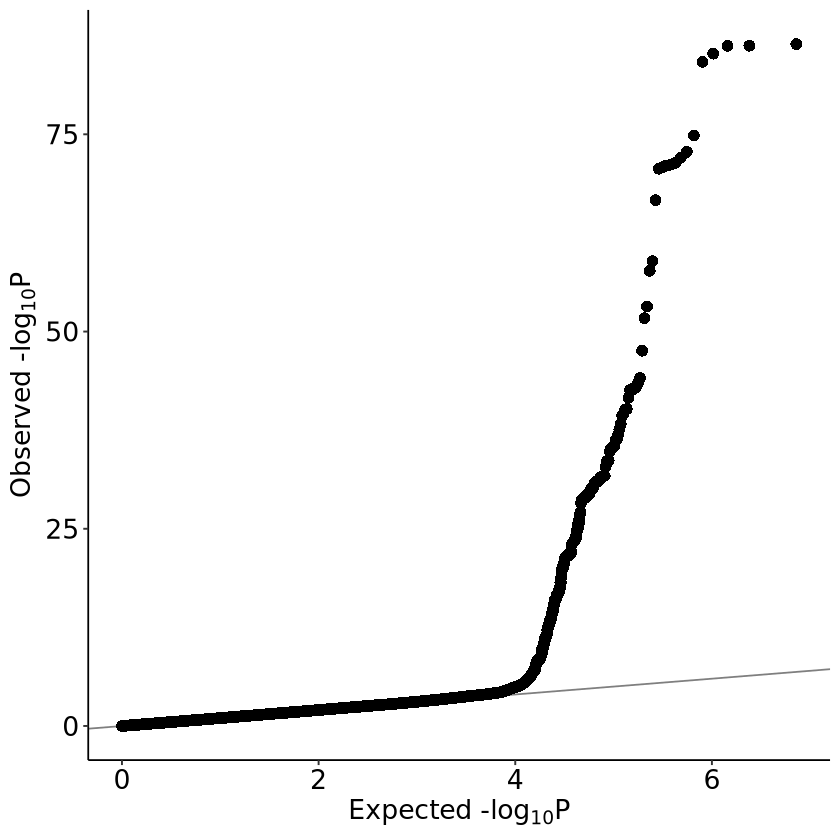

In [46]:
qq2

In [28]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_2.pdf', plot = qq2, device = "pdf", width = 3, height = 3)

In [52]:
ggsave(filename = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_2.png', plot = qq2, device = "png", width = 4, height = 4)

In [49]:
rm(AFR)

## Arrange all qq plots in a row and make a pdf

#EMPTY PLOTS
#specify path to save PDF to
destination = '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_1.pdf'

#open PDF
pdf(file=destination)

#specify to save plots in 2x2 grid
#par(mfrow = c(1,4))

#save plots to PDF
print(qq1)
print(qq2)
print(qq3)
print(qq4)

#turn off PDF plotting
dev.off() 

#With dimensions? did not work either
#Specify the path to save the PDF
destination <- '/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A.pdf'

#Create a list of plots (qq1, qq2, qq3, qq4)
plot_list <- list(qq1, qq2, qq3, qq4)

#Arrange the plots in a single row and set the size of each plot to 3x3 inches
arranged_plots <- ggarrange(plotlist = plot_list, ncol = 4, widths = rep(3, 4), heights = rep(3, 4))

#Print the arranged plots
print(arranged_plots)

#Save the arranged plots to a PDF (specify size in pixels)
ggsave(filename = destination, plot = arranged_plots, device = "pdf", width = 12, height = 6)

ggsave(
   filename = "/broad/sankaranlab/arora/hbf/reviews/figures/SupFig1A_type2.pdf", 
   plot = marrangeGrob(plot_list, nrow=1, ncol=4), 
   width = 14, height = 9
)



# Supplementary Figure 2

## 2A

In [75]:
enrich <- read.table('/broad/sankaranlab/arora/hbf/reviews/LDAK/CloudTanz_METALOUT_inv_a1alt_hapmap.gbr.enrich', header = TRUE, sep = ' ')

In [76]:
head(enrich)

,Component,Share,SD,Expected,Enrichment,SD.1,Z.Stat1,Z.Stat2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Enrich_A1,-0.052692,0.187984,0.016079,-3.277000,11.690921,-0.365839,-0.374538
2,Enrich_A2,-0.069424,0.206598,0.067402,-1.030004,3.065163,-0.662283,-0.718162
3,Enrich_A3,1.012430,0.553498,0.028542,35.472070,19.392664,1.777583,3.001014
4,Enrich_A4,0.522823,0.327101,0.336608,1.553208,0.971755,0.569288,0.569094
5,Enrich_A5,-0.472903,0.377330,0.023919,-19.771004,15.775304,-1.316679,-1.648741
6,Enrich_A6,0.146037,0.304261,0.071013,2.056482,4.284563,0.246579,0.247743


In [77]:
annotations <- read.table('/broad/sankaranlab/arora/tools/LDAK/snp_annotations/annotations.txt')

In [78]:
head(annotations)

,V1,V2
,<int>,<chr>
1,1,Coding_UCSC*
2,2,Coding_UCSC.extend.500
3,3,Conserved_LindbladToh*
4,4,Conserved_LindbladToh.extend.500
5,5,CTCF_Hoffman*
6,6,CTCF_Hoffman.extend.500


In [79]:
colnames(annotations) <- c("Number","Annotation")

In [80]:
enrich <- cbind(enrich,annotations)

In [81]:
head(enrich)

,Component,Share,SD,Expected,Enrichment,SD.1,Z.Stat1,Z.Stat2,Number,Annotation
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,Enrich_A1,-0.052692,0.187984,0.016079,-3.277000,11.690921,-0.365839,-0.374538,1,Coding_UCSC*
2,Enrich_A2,-0.069424,0.206598,0.067402,-1.030004,3.065163,-0.662283,-0.718162,2,Coding_UCSC.extend.500
3,Enrich_A3,1.012430,0.553498,0.028542,35.472070,19.392664,1.777583,3.001014,3,Conserved_LindbladToh*
4,Enrich_A4,0.522823,0.327101,0.336608,1.553208,0.971755,0.569288,0.569094,4,Conserved_LindbladToh.extend.500
5,Enrich_A5,-0.472903,0.377330,0.023919,-19.771004,15.775304,-1.316679,-1.648741,5,CTCF_Hoffman*
6,Enrich_A6,0.146037,0.304261,0.071013,2.056482,4.284563,0.246579,0.247743,6,CTCF_Hoffman.extend.500


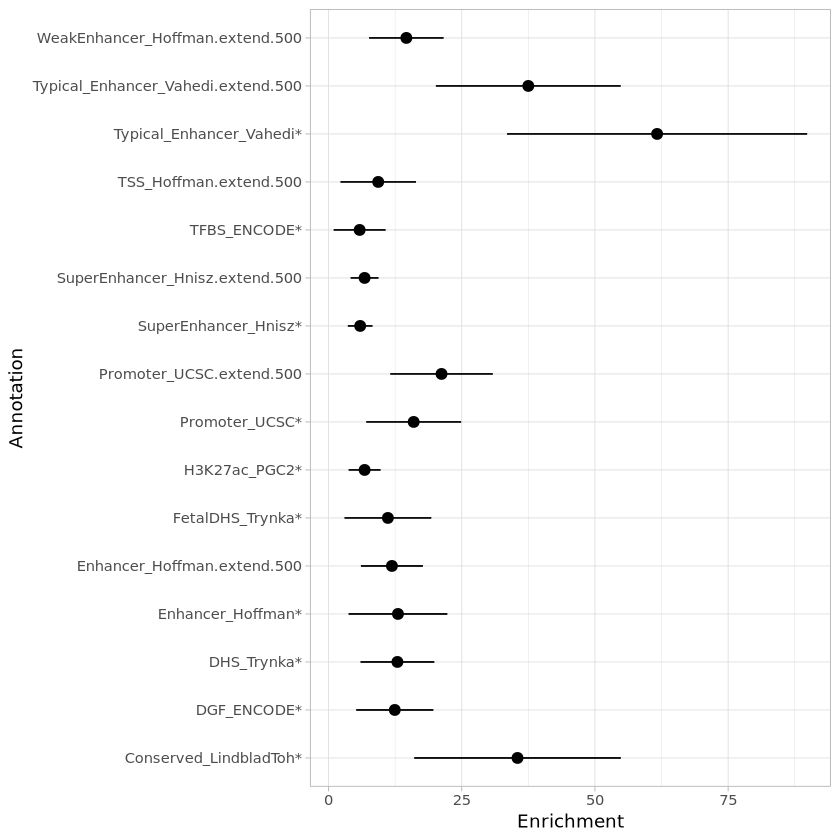

In [83]:
enrich %>%
filter(Enrichment > 5) %>%
filter(SD.1 != 0) %>%
ggplot(aes(x = Annotation, y = Enrichment)) +
geom_pointrange(aes(ymin=Enrichment-SD.1, ymax=Enrichment+SD.1)) + 
coord_flip() + 
theme_light()

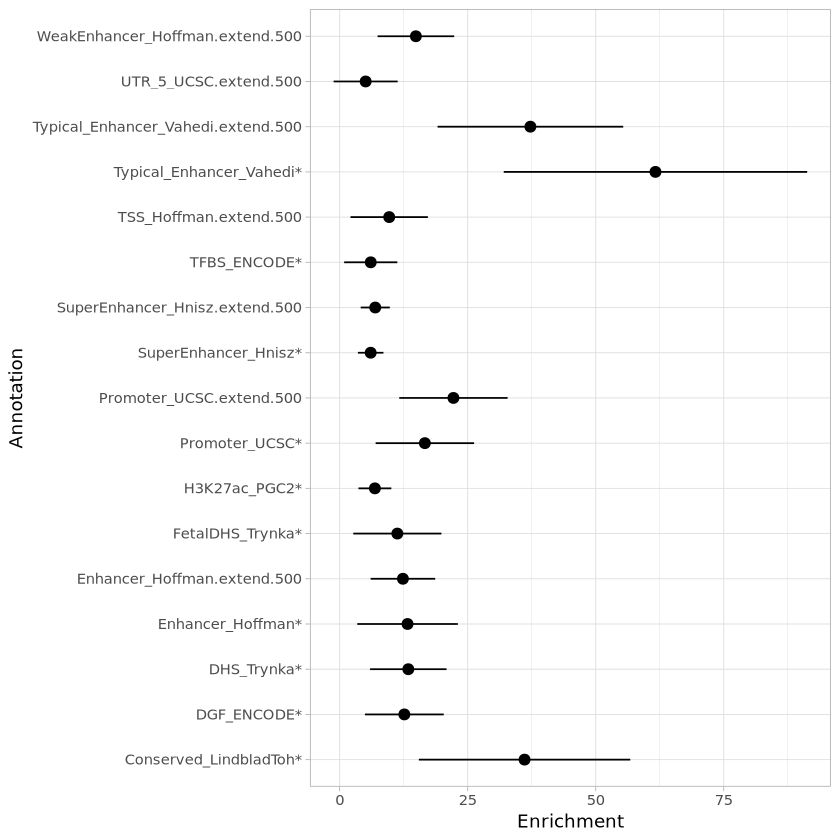

In [37]:
enrich %>%
filter(Enrichment > 5) %>%
filter(SD.1 != 0) %>%
ggplot(aes(x = Annotation, y = Enrichment)) +
geom_pointrange(aes(ymin=Enrichment-SD.1, ymax=Enrichment+SD.1)) + 
coord_flip() + 
theme_light()

In [84]:
enrich %>%
  filter(Enrichment > 5) %>%
  filter(SD.1 != 0) %>%
  mutate(Annotation = factor(Annotation, levels = Annotation[order(Enrichment)])) %>%
  ggplot(aes(x = Annotation, y = Enrichment)) +
  geom_pointrange(aes(ymin = Enrichment - SD.1, ymax = Enrichment + SD.1)) + 
  coord_flip() + 
  theme_light() -> LDAK_enrich

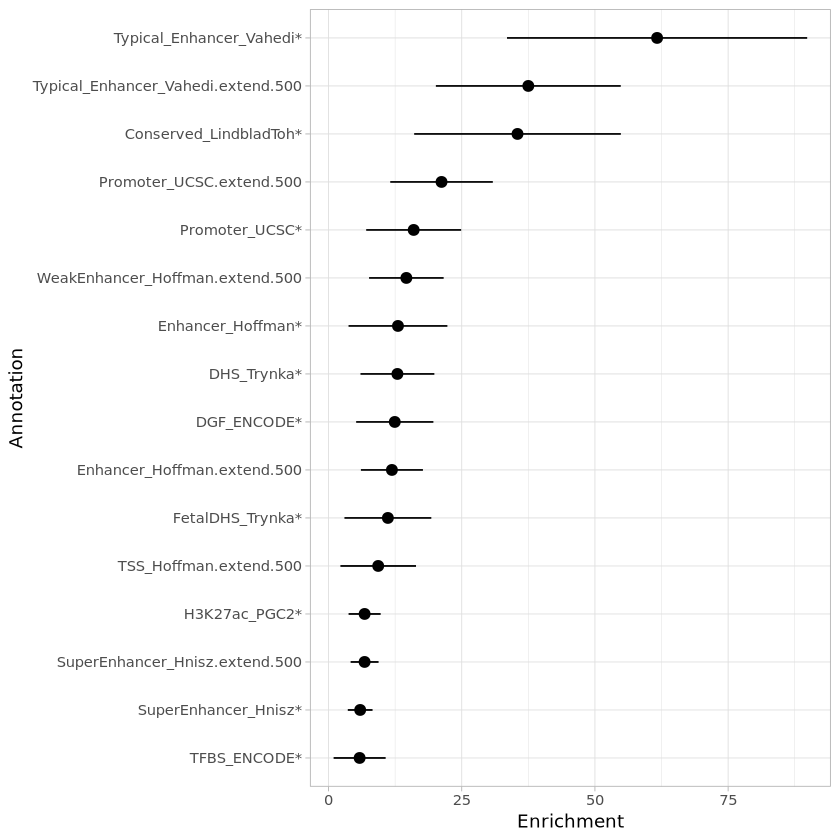

In [85]:
LDAK_enrich

In [86]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/SupFig2A.pdf", LDAK_enrich, width = 6, height = 4)

## 2B

In [21]:
files <- list.files('/broad/sankaranlab/arora/hbf/reviews/LDAK/GenCorr', pattern = "\\.thin\\.hapmap\\.gbr\\.cors$", full.names = TRUE)

In [22]:
gencorr <- data.frame(
  Component = character(),
  Value = numeric(),
  SD = numeric(),
  Sample = character(),
  stringsAsFactors = FALSE
)

In [23]:
for (filename in files) {
    thin <- read.table(filename, header = TRUE)
    result <- str_extract(basename(filename), "^[^.]+")
    thin$Sample <- result
    colnames(thin) <- c("Component","Value","SD","Sample")
    gencorr <- rbind(gencorr, thin)
}

In [24]:
head(gencorr)

,Component,Value,SD,Sample
,<chr>,<dbl>,<dbl>,<chr>
1,Her1_All,0.147433,0.076089,BAS
2,Her2_All,0.064965,0.007968,BAS
3,Coher_All,-0.012350,0.004214,BAS
4,Cor_All,-0.126189,0.052017,BAS
5,Scaling1,0.998231,0.012220,BAS
6,Scaling2,1.069493,0.025424,BAS


In [25]:
gencorr

Component,Value,SD,Sample
<chr>,<dbl>,<dbl>,<chr>
Her1_All,0.147433,0.076089,BAS
Her2_All,0.064965,0.007968,BAS
Coher_All,-0.012350,0.004214,BAS
Cor_All,-0.126189,0.052017,BAS
Scaling1,0.998231,0.012220,BAS
Scaling2,1.069493,0.025424,BAS
Overlap,0.015898,0.004661,BAS
Her1_All,0.147435,0.076087,EOS
Her2_All,0.178763,0.019942,EOS


In [29]:
gencorr %>%
filter(Component == 'Her2_All') 

Component,Value,SD,Sample
<chr>,<dbl>,<dbl>,<chr>
Her2_All,0.064965,0.007968,BAS
Her2_All,0.178763,0.019942,EOS
Her2_All,0.126011,0.012669,HCT
Her2_All,0.130452,0.014197,HGB
Her2_All,0.187979,0.016044,LYM
Her2_All,0.289033,0.053037,MCH
Her2_All,0.096473,0.014423,MCHC
Her2_All,0.288771,0.048083,MCV
Her2_All,0.196391,0.026150,MON


In [27]:
gencorr %>%
filter(Component == 'Cor_All') %>%
mutate(Value = Value * -1) %>%
ggplot(aes(x = Sample, y = Value, color = Value)) +
geom_pointrange(aes(ymin = Value - SD, ymax = Value + SD)) + 
scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
coord_flip() + 
  theme_light() -> gencorr_plot

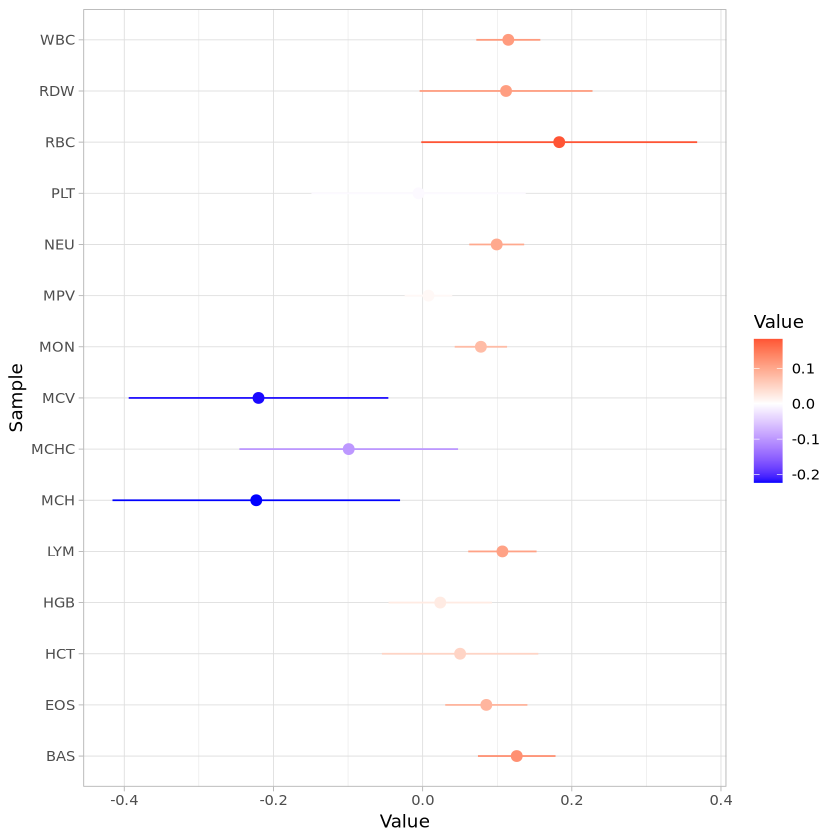

In [28]:
gencorr_plot

In [118]:
ggsave("/broad/sankaranlab/arora/hbf/reviews/figures/SupFig2B.pdf", gencorr_plot, width = 6, height = 4)

# Heritability

In [ ]:
her <- read.table('/broad/sankaranlab/arora/hbf/reviews/LDAK/CloudTanz_METALOUT_inv_a1alt_hapmap.gbr.enrich', header = TRUE, sep = ' ')

In [ ]:
## Comparing fet